# Проект. Исследование стартапов

- Автор: Луцкова Екатерина
- Дата: 21.04.26

## Введение

### Цели и задачи проекта
Цель проекта: помочь финансовой компании, работающей с венчурными инвестициями, понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. 

Задачи, которые предстоит решить:

- Провести предобработку данных.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать.

### Описание данных

Датасет получен из базы данных стартапов.

Название основного датасета — cb_investments.zip. 

Описание данных:

* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.


Описание данных:

* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### Содержимое проекта
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Инжиниринг признаков.
4. Работа с выбросами и анализ.
5. Анализ динамики.
6. Итоговые выводы и рекомендации.

## 1. Знакомство с данными: загрузка и предобработка



### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.


In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
returns_df = pd.read_csv('/datasets/cb_returns.csv')

Познакомимся с данными и изучим общую информацию о них, чтобы принять решение о предобработке.

In [4]:
df_len = len(df)
print(df_len)

54294


In [5]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Все 40 столбцов не поместились в выгрузку. Вызовем их по индексам отдельной таблицей.

In [6]:
df.iloc[:, 10:30].head()

,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt
0,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0
1,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0
4,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Выведем уникальные названия столбцов, чтобы исключить некорректные названия и ошибки.

In [8]:
print(df.columns.tolist())

['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


Датасет cb_investments.csv содержит 40 столбцов и 54294 строк, в которых представлена информация о компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов соответствуют стандарту snake_case. Однако в 2х из них обнаружены лишние пробелы.

Представленные данные содержат как текстовые, так и числовые значения. Большинство данных - 24 столбца - хранятся в типе float64 и 16 столбцов - в типе object. Столбцы с булевыми значениями отсутствуют.

Данные в столбцу `funding_total_usd` хранятся в типе object, хотя представлены дробным числом (суммой финансирования). Для данных больше подходит числовой тип float.

Столбцы `funding_rounds` и `participants` имеют числовой тип float64, хотя представлены целыми числами. Этим данным больше подходит тип integer.

Столбцы `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at` имеют текстовый тип object, хотя представлены датой. Потребуется привести их к соответствующему типу данных - datetime.

Столбцы `founded_month`, `founded_quarter` имеют тип object, а `founded_year` - тип float64. При этом данные столбцы представлены целыми числами (месяц, квартал и год не могут быть дробными числами). Этим данным больше подходит тип integer.

Размерность данных во всех столбцах можно будет оптимизировать.

Пропуски содержатся во всех столбцах. При этом можно заменить, что несколько столбцов содержат одинаковое количество строк - 49438.

Теперь познакомимся с данными датасета cb_returns.csv.

In [9]:
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [10]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет cb_returns.csv содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов соответствуют стандарту snake_case.

Представленные данные хранятся в типах int64 и float64. Указанные типы соответствуют содержанию, поэтому менять тип не придется.

Размерность данных во всех столбцах можно будет оптимизировать.

Пропусков в столбцах нет.

Судя по первому знакомству с данными, значения в обоих датасетах соответствуют своему описанию и выглядят корректно. 

### 1.2. Предобработка данных

Нормализуем названия столбцов `market` и `funding_total_usd` - уберем лишние пробелы в начале и в конце.

In [11]:
df = df.rename(columns = {' market ': 'market', ' funding_total_usd ': 'funding_total_usd'})

Также нормализуем значения в столбце `market` - уберем лишние пробелы в начале сегментов.

In [12]:
df['market'] = df['market'].str.replace(' ', '')

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [13]:
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')

In [14]:
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors = 'coerce')

Преобразуем тип данных в столбцах, хранящих целочисленные значения, заменив пропуски на нулевое значение.

In [15]:
for column in ('founded_month', 'founded_quarter', 'founded_year'):
    df[column] = pd.to_numeric(df[column], errors = 'coerce')

In [16]:
for column in ('funding_rounds', 'participants', 'founded_month', 'founded_quarter', 'founded_year'):
    df[column] = df[column].fillna(0).astype(int)

Преобразуем тип данных в столбцах, хранящий дату

In [17]:
for column in ('founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at'):
    df[column] = pd.to_datetime(df[column], errors = 'coerce')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [18]:
returns_df = returns_df.set_index('year')

Изучим пропущенные значения и посчитаем, сколько пропусков в столбцах основного датафрейма, в абсолютном и относительном выражениях.

In [19]:
df.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
market                   8817
funding_total_usd       13387
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds              0
participants                0
founded_at              15741
founded_month               0
founded_quarter             0
founded_year                0
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [20]:
df.isna().sum() / df.shape[0]

name                    0.089457
homepage_url            0.152963
category_list           0.162394
market                  0.162394
funding_total_usd       0.246565
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.000000
participants            0.000000
founded_at              0.289922
founded_month           0.000000
founded_quarter         0.000000
founded_year            0.000000
first_funding_at        0.089623
mid_funding_at          0.442148
last_funding_at         0.089549
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

Пропуски обнаружены во всех столбцах, кроме `funding_rounds`, `participants`, `founded_month`, `founded_quarter` и `founded_year` (пропуски в них мы ранее заполнили значением "0"). Процент пропуска составляет от 9% до 44%.

Причины появления пропусков могут быть различными, но поскольку данные исторические и отсчитываются с 17го века, то можно предположить, что информация попросту была утеряна в процессе переноса на цифровые ресурсы или вовсе не фиксировалась. 

Менее 10% пропусков обнаружено в столбцах (`seed` - `round_H`), отображащих суммы инвестиций по разным типам финансирования и суммы по раундам финансирования. Небольшой процент пропусков позволяет проигнорировать их. Более того, было бы некорректно заполнять их каким-либо средним/медианным значением либо индикатором, чтобы не исказить результаты.

На полноту анализа оказывает наибольшее влияние столбец о сумме финансирования - `funding_total_usd`. Строки с пропусками в данном столбце можно будет удалить, поскольку они все равно не принесут никакой пользы анализу.

Столбцы со строковыми данными `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city` содержат довольно много пропусков. Заполним их значением-заглушкой "нет данных", посколько заполнить пропуски каким-либо содержательным значением не представляется возможным.

В качестве нового значения вместо пропусков в столбце `mid_funding_at` возьмем приблизительно середину интервала между этими двумя датами `first_funding_at` и `last_funding_at`.

Заполним пропуски в текстовых данных на значение-индикатор - "нет данных". 

In [21]:
for column in ('name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city'):
    df[column] = df[column].fillna('нет данных')

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [22]:
df.duplicated().sum()

4855

В данных обнаружено 4855 явных дубликатов. Удалим строки с полными дубликатами.

In [23]:
df = df.drop_duplicates()

Теперь проверим, сколько пропусков в ключевом столбце `funding_total_usd` и удалим строки, которые содержат пропуски.

In [24]:
df['funding_total_usd'].isna().sum()

8532

In [25]:
df = df.dropna(subset=['funding_total_usd'])

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

Подсчитаем количество пропусков в столбце `mid_funding_at` и заполним их на основании значений в столбцах `first_funding_at` и `last_funding_at`. 

In [26]:
df['mid_funding_at'].isna().sum()

13676

In [27]:
date_diff = df['last_funding_at'] - df['first_funding_at']

half_diff = date_diff / 2

mid_date = df['first_funding_at'] + half_diff

In [28]:
df['mid_funding_at'] = df['mid_funding_at'].fillna(mid_date)

Узнаем, сколько пропусков осталось в столбце `mid_funding_at` после заполнения их центральным значением.

In [29]:
df['mid_funding_at'].isna().sum()

1

После предобработки данных и удаления строк-дубликатов, а также строк не содержащих данных о финансировании, в датафрейме осталось 40 907 строк. Подсчитаем процент удаленных данных от изначального массива.

In [30]:
df_len_new = len(df)
print(df_len_new)

40907


In [31]:
deleted_share = (df_len - df_len_new) / df_len
print(deleted_share)

0.24656499797399345


Подсчет показал, что почти 25% данных было удалено по тем или иным причинам. Оставшихся данных будет достаточно для анализа.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Создадим дополнительный столбец, содержащий принадлежность к какой-либо группе.

In [32]:
def categorize_funding(row):
    funding_rounds = row['funding_rounds']
    first_date = row['first_funding_at']
    last_date = row['last_funding_at']
    days_diff = (last_date - first_date).days

    if funding_rounds == 1:
        return 'Единичное финансирование'
    elif days_diff <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df['funding_category'] = df.apply(categorize_funding, axis = 1)       


  Проверим, сколько компаний оказалось в каждой из категорий.

In [33]:
df['funding_category'].value_counts()

Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_category, dtype: int64

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

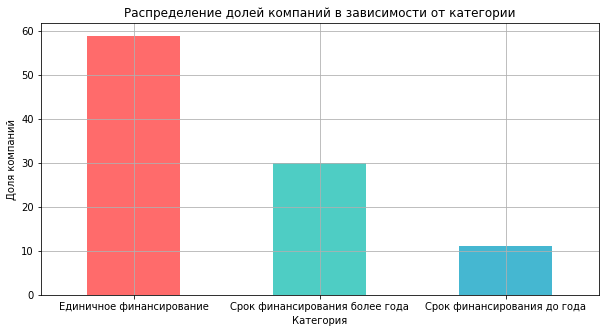

In [34]:
grouped_name = df.groupby('funding_category')['name'].count()
percentages = (grouped_name / grouped_name.sum() * 100).round(1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

percentages.plot(kind='bar',
               title=f'Распределение долей компаний в зависимости от категории',
               legend=False,
               color = colors,
               ylabel='Доля компаний',
               xlabel='Категория',
               rot=0,
               figsize=(10, 5))
plt.grid()

plt.show()

На графике видно, что процент компаний, получивших единичное финансирование почти достиг 60%. Компаний, которые получали финансирование более года - 30%, а компаний, которые финансировались менее года, чуть больше 10%.

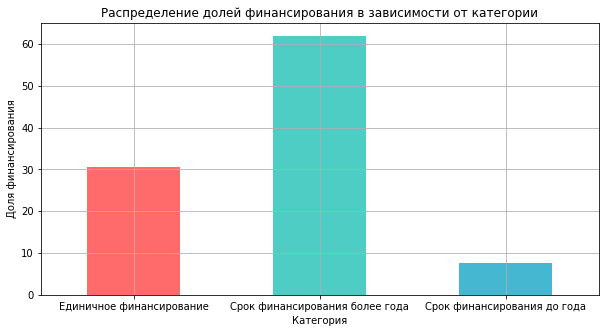

In [35]:
grouped_funding = df.groupby('funding_category')['funding_total_usd'].sum()

total_funding = grouped_funding.sum()

percentages = (grouped_funding / total_funding * 100).round(1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

percentages.plot(kind='bar',
               title=f'Распределение долей финансирования в зависимости от категории',
               legend=False,
               color = colors,
               ylabel='Доля финансирования',
               xlabel='Категория',
               rot=0,
               figsize=(10, 5))
plt.grid()

plt.show()

График показывает, что наибольшую долю финансирования от общего объёма привлечённых средств получила категория "Срок финансирования более года" (больше 60%), наименьшую - "Срок финансирования до года" (меньше 10%).

### 2.2 Выделение средних и нишевых сегментов рынка

Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

In [36]:
market_counts = df['market'].value_counts()

def categorize_segment(count):
    if count > 120:
        return 'Массовый сегмент'
    elif 35 <= count <= 120:  
        return 'Средний сегмент'
    else:  
        return 'Нишевый сегмент'

segment_categories = market_counts.apply(categorize_segment)

segments_info = pd.DataFrame({
    'company_count': market_counts,
    'segment_category': segment_categories
})

category_counts = segments_info['segment_category'].value_counts()
print(category_counts)

Нишевый сегмент     289
Средний сегмент      57
Массовый сегмент     49
Name: segment_category, dtype: int64


Узнаем, как это выглядит в процентном соотношении и построим соответствующий график.

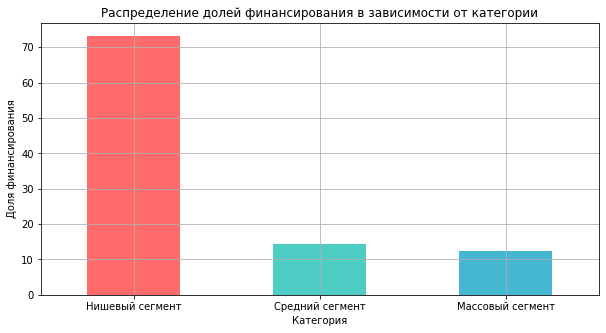

In [37]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

total_count = category_counts.sum()

category_percentages = (category_counts / total_count * 100).round(1)

category_percentages.plot(kind='bar',
               title=f'Распределение долей финансирования в зависимости от категории',
               legend=False,
               color = colors,
               ylabel='Доля финансирования',
               xlabel='Категория',
               rot=0,
               figsize=(10, 5))
plt.grid()

plt.show()

Построим график распределения количества компаний в сегментах.

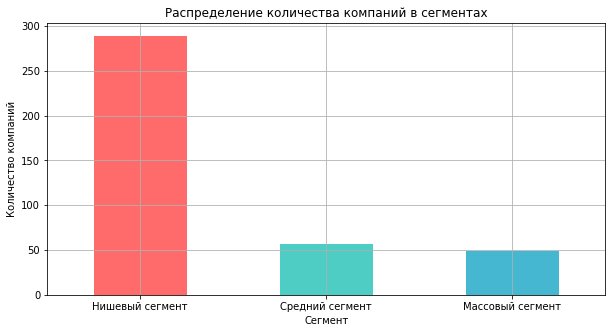

In [38]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

category_counts.plot(kind='bar',
               title=f'Распределение количества компаний в сегментах',
               legend=False,
               color = colors,
               ylabel='Количество компаний',
               xlabel='Сегмент',
               rot=0,
               figsize=(10, 5))
plt.grid()

plt.show()

Анализ показал интересное распределение компаний по сегментам. Львиная доля (более 70%) стартапов относится к нишевым, при том, что в каждом из нишевых сегментов занято меньше 35 компаний. Любопытно, что в совокупности они занимают большую половину рынка. Делаем вывод, что чаще всего стартапы создаются и регистрируются в тех сегментах и отраслях, которые еще не были ранее освоены другими. Данные сегменты могут быть связаны с уникальными разработками и технологиями, которых с каждым днем появляется все больше и которые еще не были зарегистрированы ранее. Однако такие сегменты все еще остаются нишевыми, поскольку для того чтобы они стали массовыми, или хотя бы средними, прошло еще слишком мало времени.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [39]:
market_counts = df['market'].value_counts()

market_to_count = market_counts.to_dict()

def replace_segment(market_name):
    count = market_to_count[market_name]  
    if count > 120:
        return market_name  
    elif 35 <= count <= 120:
        return 'mid'  
    else:  
        return 'niche' 

df['market'] = df['market'].apply(replace_segment)

Убедимся, что замена в столбце `market` осуществилась.

In [40]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_category
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
1,University of New Brunswick,http://www.unb.ca,нет данных,нет данных,2000000.0,operating,нет данных,нет данных,нет данных,нет данных,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование


## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

Для этого проверим, как распределены данные в столбце `funding_total_usd` и узнаем, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

In [41]:
df['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Теперь продемонстрируем информацию на графике, убрав отображение выбросов.

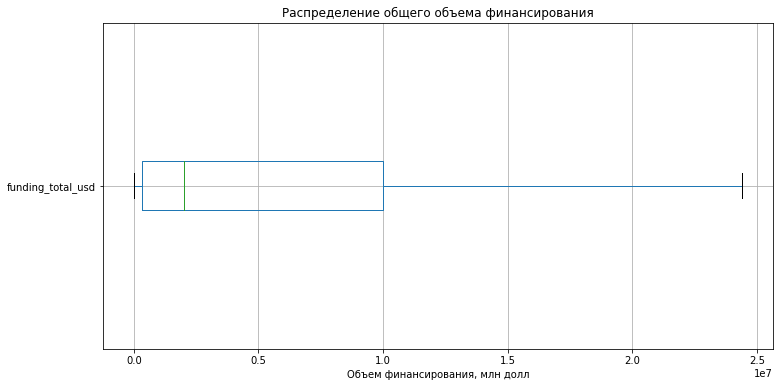

In [42]:
plt.figure(figsize=(12, 6))

df.boxplot(column='funding_total_usd', vert=False, showfliers=False)

plt.title('Распределение общего объема финансирования')
plt.xlabel('Объем финансирования, млн долл')

plt.show()


Видим, что основная часть значений лежит в промежутке до 500 000 долл, с медианой около 200 000 долл.

Вычислим аномальное финансирование с помощью IQR. Вначале вычислим квартили Q1 и Q3.

In [43]:
Q1 = df['funding_total_usd'].quantile(0.25)
Q3 = df['funding_total_usd'].quantile(0.75)
print(Q1)
print(Q3)

350000.0
10000000.0


Рассчитаем межквартильный размах IQR

In [44]:
IQR = Q3 - Q1
print(IQR)

9650000.0


Создадим дополнительный столбец с признаком, получила ли компания аномальное финансирование или нет

In [45]:
def find_anomaly(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    anomaly_mask = (series < lower_bound) | (series > upper_bound)

    return anomaly_mask


df['is_anomaly'] = df.groupby('market')['funding_total_usd'].apply(find_anomaly)

Вычислим, сколько компаний получило аномальное финансирование.

In [46]:
df['is_anomaly'].value_counts()

False    35663
True      5244
Name: is_anomaly, dtype: int64

Выяснили, что всего 5244 компании получили аномальное финансирование. 

Теперь выясним, компании каких сегментов чаще всего получали аномальное финансирование. 

In [47]:
anomaly_market = df.groupby('market')['is_anomaly'].mean().sort_values(ascending = False)
print(anomaly_market)

market
RealEstate            0.172043
Entertainment         0.166667
Consulting            0.166189
Search                0.164948
CloudComputing        0.164474
Photography           0.161765
SaaS                  0.161765
Technology            0.159664
Video                 0.159574
niche                 0.159036
Travel                0.154545
Networking            0.153846
Internet              0.153527
BigData               0.153333
Marketplaces          0.153061
нет данных            0.149021
mid                   0.144754
E-Commerce            0.144159
Apps                  0.143498
Automotive            0.141935
Medical               0.139073
Sports                0.137255
SocialMedia           0.135593
News                  0.132890
Education             0.132701
Fashion               0.132013
Mobile                0.131826
Hospitality           0.130952
HealthandWellness     0.129439
Messaging             0.128814
CleanTechnology       0.127966
Startups              0.127820
S

Топ-5 таких сегментов: RealEstate, Entertainment, Consulting, Search и CloudComputing.
Теперь определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [48]:
filtered_df_market = df.loc[(df['is_anomaly'] == True) & (df['market'] != 'mid') & (df['market'] != 'niche')] 

anomaly_company_market = filtered_df_market.groupby('market')['name'].count().sort_values(ascending = False)
print(anomaly_company_market)

market
Software              576
Biotechnology         382
нет данных            373
Mobile                309
E-Commerce            269
CuratedWeb            202
CleanTechnology       151
EnterpriseSoftware    146
SocialMedia           136
Advertising           136
HealthCare            128
Hardware+Software     123
Games                 117
HealthandWellness     113
Education             112
Finance               104
Analytics              82
Security               66
Manufacturing          63
Consulting             58
Travel                 51
RealEstate             48
Search                 48
Hospitality            44
SaaS                   44
WebHosting             43
Fashion                40
News                   40
Messaging              38
Technology             38
Internet               37
Semiconductors         34
Music                  33
Photography            33
Apps                   32
Marketplaces           30
Video                  30
Sports                 28
Enter

Больше всего компаний, получивших аномальное финансирование, принадлежат к сегментам Biotechnology, Software и сегменту Mobile. 

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что предоставлены полные данные за 2014 год. Будем считать,что критерием полноты служат информация о созданных в этот период компаниях, а также информация о поступающем финансировании.
Проверим, сколько компаний было зарегистрировано в 2014 году.

In [49]:
df['founded_at_year'] = df['founded_at'].dt.year

In [50]:
filtered_year = df.loc[df['founded_at_year'] == 2014]
row_count = len(filtered_year)
print(row_count)

1015


Анализ показал, что за 2014 год есть информация о 1015 зарегистрированных компаниях.
Посмотрим, есть ли информация о поступающем финансировании (сколько компаний получало финансирование). Проверим информацию по 2 столбцам: `first_funding_at` и `last_funding_at`.

In [51]:
df['first_funding_at_year'] = df['first_funding_at'].dt.year

df['last_funding_at_year'] = df['last_funding_at'].dt.year

In [52]:
filtered_funding_year = df.loc[(df['first_funding_at_year'] == 2014) | (df['last_funding_at_year'] == 2014)]
row_count_fund = len(filtered_funding_year)
print(row_count_fund )

11915


Проверим, как финансирование распределялось по месяцам. 
Сначала выделим год (2014) первого и последнего финансирования, а затем сделаем разбивку по месяцам.

In [53]:
df_2014 = df[df['first_funding_at'].dt.year == 2014]
funding_per_month = df_2014['first_funding_at'].dt.month.value_counts().sort_index()
print(funding_per_month)

1     810
2     635
3     661
4     593
5     549
6     669
7     671
8     525
9     538
10    492
11    311
12     23
Name: first_funding_at, dtype: int64


In [54]:
df_2014_last = df[df['last_funding_at'].dt.year == 2014]
funding_per_month_last = df_2014_last['last_funding_at'].dt.month.value_counts().sort_index()
print(funding_per_month_last)

1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1135
10    1139
11     732
12      52
Name: last_funding_at, dtype: int64


Видим, что в датасете есть информация о 11915 компаниях, которые получали какое-либо финансирование в 2014 году. 
Однако видим, что полная информация о финансировании имеется по всем месяцам года за исключением декабря. В декабре наблюдается резкое падение количества данных.

Учитывая факторы, описанные выше, будем считать, что данные за 2014 год предоставлены не совсем в полной мере. Информация присутствует за 11 месяцев года.

Исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

In [55]:
df = df[df['is_anomaly'] == False]

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только о тех компаниях, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [56]:
df['mid_funding_year'] = df['mid_funding_at'].dt.strftime('%Y')
year_rounds = df.groupby('mid_funding_year', as_index=False)['funding_rounds'].sum()
activity_years = year_rounds[year_rounds['funding_rounds'] > 50]
activity_years.sort_values(by='mid_funding_year')

,mid_funding_year,funding_rounds
18,2000,113
19,2001,66
20,2002,98
21,2003,125
22,2004,181
23,2005,948
24,2006,1849
25,2007,2842
26,2008,3663
27,2009,4617


In [57]:
df['mid_funding_year'] = pd.to_numeric(df['mid_funding_year'])
filtered_df = df.loc[df['mid_funding_year'].between(2000, 2014)].copy()

Проверим, сколько компаний осталось после удаления строк.

In [58]:
print(f'Количество компаний после фильтрации: {len(filtered_df)}')

Количество компаний после фильтрации: 35588


### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. 

In [59]:
total_funding = {}

for column in ('seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'):
    total_funding[column] = filtered_df[column].sum()

total_funding_sorted = pd.Series(total_funding).sort_values(ascending=False)


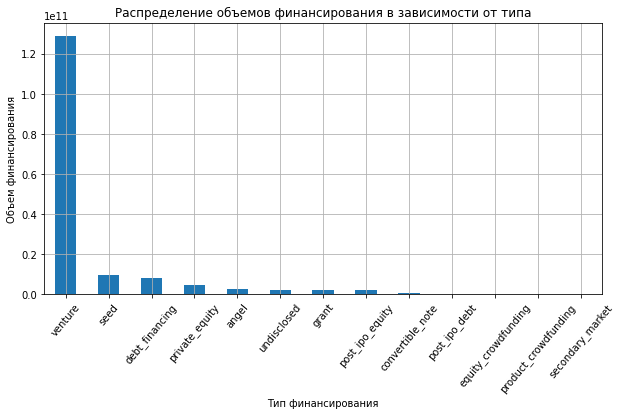

In [60]:
total_funding_sorted.plot(kind='bar',
               title=f'Распределение объемов финансирования в зависимости от типа',
               legend=False,
               ylabel='Объем финансирования',
               xlabel='Тип финансирования',
               rot=50,
               figsize=(10, 5))


plt.grid()
plt.show()

Построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

In [61]:
fund_type_count = {}

for column in ('seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'):
    count = (filtered_df[column] > 0).sum() 
    fund_type_count[column] = count

counts_sorted = pd.Series(fund_type_count).sort_values(ascending=False)

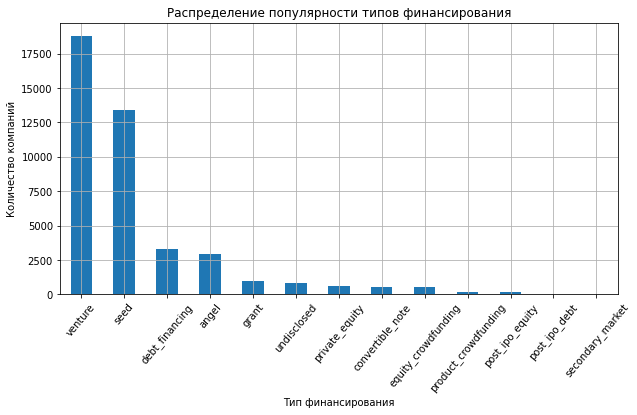

In [62]:
counts_sorted.plot(kind='bar',
               title=f'Распределение популярности типов финансирования',
               legend=False,
               ylabel='Количество компаний',
               xlabel='Тип финансирования',
               rot=50,
               figsize=(10, 5))


plt.grid()
plt.show()

На графиках видим, что наибольшей популярностью пользуется "венчурный" тип финансирования, он же лидирует по объемам предоставленных средств. При этом тип финансирования seed хоть и встречается довольно часто (2-е место по популярности) привлекает довольно мало средств. А вот тип финансирования private_equity не столь популярен, зато находится на 4 месте по объемам вложений.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [63]:
total_return = {}

for column in ('seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'):
    total_return[column] = returns_df[column].sum()

total_return_sorted = pd.Series(total_return).sort_values(ascending=False)

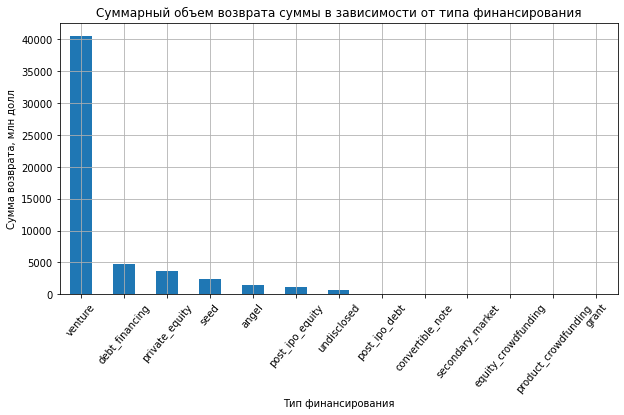

In [64]:
total_return_sorted.plot(kind='bar',
               title=f'Суммарный объем возврата суммы в зависимости от типа финансирования',
               legend=False,
               ylabel='Сумма возврата, млн долл',
               xlabel='Тип финансирования',
               rot=50,
               figsize=(10, 5))
plt.grid()
plt.show()

График показывает, что лидерами по суммарному объему возврата суммы выступают следующие типы финансирования: venture, debt_financing и private_equity.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

In [65]:
import numpy as np

filtered_df['avg_funding_per_round'] = np.nan

valid_mask = filtered_df['funding_rounds'] > 0

filtered_df.loc[valid_mask, 'avg_funding_per_round'] = (filtered_df.loc[valid_mask, 'funding_total_usd'] / filtered_df.loc[valid_mask, 'funding_rounds'])

Построим график, отражающий динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования. Для исследования возьмем за основу столбец `mid_funding_year`.

In [66]:
filtered_df['mid_funding_year'] = filtered_df['mid_funding_year'].astype('int')

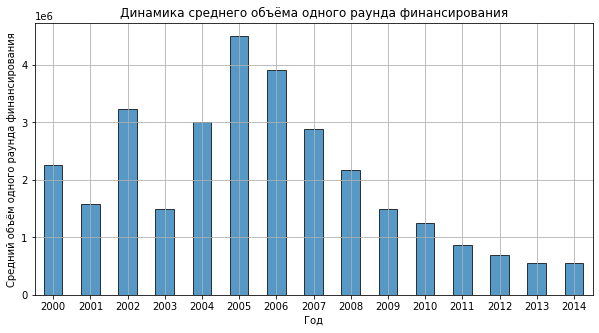

In [67]:
avg_funding_per_year = filtered_df.groupby('mid_funding_year')['avg_funding_per_round'].median()

plt.figure(figsize=(10, 5))

avg_funding_per_year.plot(
                kind='bar', 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

plt.title('Динамика среднего объёма одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Средний объём одного раунда финансирования')

plt.grid()

plt.show()

Теперь покажем динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке. 

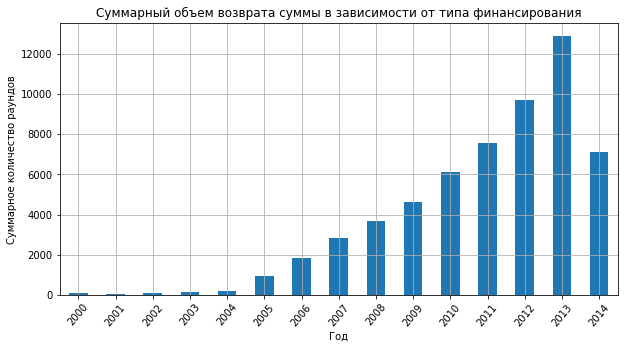

In [68]:
rounds_per_year = filtered_df.groupby('mid_funding_year')['funding_rounds'].sum()

rounds_per_year.plot(kind='bar',
               title=f'Суммарный объем возврата суммы в зависимости от типа финансирования',
               legend=False,
               ylabel='Суммарное количество раундов',
               xlabel='Год',
               rot=50,
               figsize=(10, 5))
plt.grid()
plt.show()

На графике видно, что типичный размер средств, собранных в рамках одного раунда, был максимальным в 2005 году - свыше 5 000 000 долл.
При этом в 2014 году наблюдаем отрицательную динамику: есть существенное снижение среднего объема инвестиций за один раунд - он не превышает и 1 млн, а также значительное падение количества самих раундов финансирования - около 7000 против 12000 в 2013 году.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой укажем суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. 

In [69]:
pivot_funding_sum = pd.pivot_table(filtered_df,
                             index='mid_funding_year',
                             columns='market',
                             values='funding_total_usd',
                             aggfunc="sum")

print(pivot_funding_sum)

market            Advertising    Analytics        Apps   Automotive  \
mid_funding_year                                                      
2000               14470000.0   14822803.0         NaN          NaN   
2001                8778321.0          NaN         NaN          NaN   
2002               24500000.0    7500000.0         NaN          NaN   
2003               10500000.0    3840000.0         NaN    4530000.0   
2004                6000000.0    3000000.0         NaN          NaN   
2005              127196022.0   79014044.0         NaN   22500000.0   
2006              299299458.0  139701311.0   1310600.0   12660000.0   
2007              556704331.0   98829000.0         NaN   37712601.0   
2008              622673464.0  208077840.0   4300000.0   59478635.0   
2009              563446005.0  140949327.0   7219000.0   20800311.0   
2010              631617869.0  253739903.0   6123779.0   17696916.0   
2011              410730737.0  443333373.0  18374071.0   76452163.0   
2012  

Отберем те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013

In [70]:
result = pivot_funding_sum.loc[:, pivot_funding_sum.loc[2014] > pivot_funding_sum.loc[2013]]
print(result)

market                  Apps     BigData      Design     Internet  \
mid_funding_year                                                    
2000                     NaN         NaN         NaN   10000000.0   
2001                     NaN         NaN         NaN          NaN   
2002                     NaN         NaN         NaN    1100000.0   
2003                     NaN         NaN         NaN          NaN   
2004                     NaN         NaN         NaN   10500000.0   
2005                     NaN         NaN   9300000.0    1775000.0   
2006               1310600.0         NaN    707000.0       5000.0   
2007                     NaN   7780000.0  10800000.0    4495379.0   
2008               4300000.0   2452515.0   5944302.0   23412964.0   
2009               7219000.0    597375.0   2150144.0   38195773.0   
2010               6123779.0  39233297.0  17239975.0   36657500.0   
2011              18374071.0  60369158.0   8899967.0   36859032.0   
2012              32601125.0  8641

Массовые сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013: 'Apps', 'BigData', 'Design', 'Internet', 'Manufacturing', 'Medical', 'RealEstate', 'SaaS', 'Startups', 'Technology'.
Отметим, что достаточный для анализа пул данных лежит в периоде с 2005 по 2014 год, информация присутствует практически по всем сегментам. Возьмем этот период для дальнейшего анализа.

С помощью графика изучим, как менялся суммарный размер общего финансирования в каждом из сегментов по годам (2005-2014). Рассмотрим только массовые сегменты, а средние и нишевые исключим.

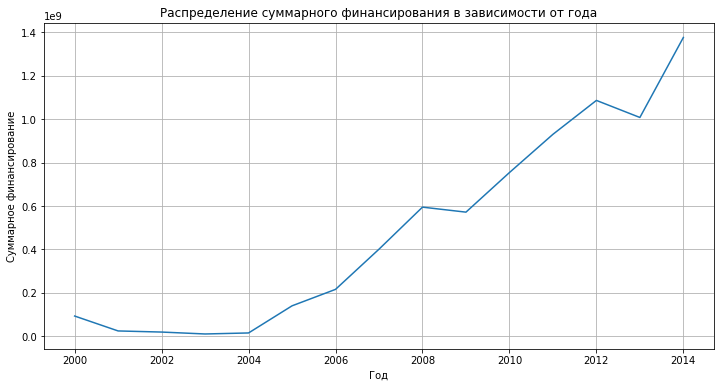

In [80]:
markets_list = ['Apps', 'BigData', 'Design', 'Internet', 'Manufacturing', 'Medical', 'RealEstate', 'SaaS', 'Startups', 'Technology']


filtered_by_year = filtered_df[filtered_df['mid_funding_year'].between(2000, 2014)].copy()


funding_df = filtered_by_year[filtered_by_year['market'].isin(markets_list)].copy()


grouped_funding_by_year = funding_df.groupby(['mid_funding_year'])['funding_total_usd'].sum()

grouped_funding_by_year.plot(kind='line',
               title=f'Распределение суммарного финансирования в зависимости от года',
               legend=False,
               ylabel='Суммарное финансирование',
               xlabel='Год',
               rot=0,
               figsize=(12, 6))
plt.grid()

plt.show()


На графике видим, что финансирование по отобранным сегментам достигает своего пика к 2014 году. Начиная с 2004 года суммарное финансирование демонстрирует устойчивый рост с небольшим падением в 2009 году и далее непрерывным ростом к 2012-му. Незначительный спад был зафиксирован в 2013 году. 

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств.

Чтобы узнать, какую долю возвращённые средства составляют от предоставленных, создадим новый датафрейм `grouped_funding`, в котором сгруппируем по годам суммарное финансирование по разным типам. Так, он будет иметь такую же структуру, что и датафрейм `returns_df` - год (установленный в качестве индекса) и информацию об инвестициях. 
Затем разделим `returns_df` на только что созданный датафрейм, сохраним результат в датафрейм `returns_share_per_year`.

In [72]:
df_cleaned = filtered_df.loc[:, [
    'mid_funding_year', 'seed', 'venture', 'equity_crowdfunding',
    'undisclosed', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]]

In [73]:
grouped_funding = df_cleaned.groupby('mid_funding_year').sum()
print(grouped_funding)

                          seed       venture  equity_crowdfunding  \
mid_funding_year                                                    
2000              1.675914e+07  3.279622e+08                  0.0   
2001              2.667675e+06  2.175191e+08                  0.0   
2002              1.046519e+07  3.069406e+08                  0.0   
2003              1.531836e+07  3.722344e+08                  0.0   
2004              1.810473e+07  6.641505e+08                  0.0   
2005              3.942520e+07  4.809711e+09                  0.0   
2006              6.679477e+07  9.020604e+09             933057.0   
2007              1.922965e+08  1.206209e+10                  0.0   
2008              3.020030e+08  1.423473e+10                  0.0   
2009              2.843514e+08  1.475536e+10            2049671.0   
2010              5.038089e+08  1.659551e+10            7400000.0   
2011              1.166553e+09  1.526826e+10            3091684.0   
2012              1.916137e+09  1.

Чтобы узнать, какую долю возвращённые средства составляют от предоставленных, разделим датафрейм `returns_df` на только что созданный датафрейм `grouped_funding`, имеющий аналогичную структуру. Сохраним результат в новый датафрейм `returns_share_per_year`. 

А поскольку возвраты измеряются в миллионах долларов, а инвестиции просто в долларах, умножим полученный результат на миллион.

In [74]:
returns_share_per_year = returns_df.div(grouped_funding + 1e-60) * 1000000

In [75]:
print(returns_share_per_year.head(20))

         angel  convertible_note  debt_financing  equity_crowdfunding  grant  \
year                                                                           
2000  0.266956               NaN        0.618571         0.000000e+00    0.0   
2001  1.180000               NaN        0.770258         0.000000e+00    0.0   
2002  1.136667               NaN        0.223388         0.000000e+00    0.0   
2003  0.605720               NaN        1.038095         0.000000e+00    0.0   
2004  0.833504               NaN        0.439698         0.000000e+00    0.0   
2005  0.509894               NaN        0.344964         0.000000e+00    0.0   
2006  0.674853               NaN        0.803772         2.036317e-01    0.0   
2007  0.817837               NaN        0.602488         1.000000e+64    0.0   
2008  0.412476               NaN        0.927484         3.000000e+64    0.0   
2009  0.615945               NaN        0.388249         8.781897e-02    0.0   
2010  0.639779               NaN        

Определим и заменим на пропуски выбросы, которые в дальнейшем повляют на анализ. Будем считать выбросами результат свыше 150%. Отфильтруем такие значения и заменим их на пропуск Nan.

In [76]:
returns_share_per_year_filtered = returns_share_per_year.copy()
returns_share_per_year_filtered[returns_share_per_year > 1.5] = np.nan
print(returns_share_per_year_filtered)

         angel  convertible_note  debt_financing  equity_crowdfunding  grant  \
year                                                                           
2000  0.266956               NaN        0.618571             0.000000    0.0   
2001  1.180000               NaN        0.770258             0.000000    0.0   
2002  1.136667               NaN        0.223388             0.000000    0.0   
2003  0.605720               NaN        1.038095             0.000000    0.0   
2004  0.833504               NaN        0.439698             0.000000    0.0   
2005  0.509894               NaN        0.344964             0.000000    0.0   
2006  0.674853               NaN        0.803772             0.203632    0.0   
2007  0.817837               NaN        0.602488                  NaN    0.0   
2008  0.412476               NaN        0.927484                  NaN    0.0   
2009  0.615945               NaN        0.388249             0.087819    0.0   
2010  0.639779               NaN        

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

In [77]:
columns = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

normalized_values = returns_share_per_year_filtered[columns]

print("Нормированные значения по типам финансирования:")
print(normalized_values)

Нормированные значения по типам финансирования:
       venture  debt_financing  private_equity      seed     angel
year                                                              
2000  0.168922        0.618571        0.000000  0.996471  0.266956
2001  0.107991        0.770258        0.000000  1.079592  1.180000
2002  0.682282        0.223388        0.201333  0.629707  1.136667
2003  0.628260        1.038095             NaN  0.505276  0.605720
2004  0.837009        0.439698             NaN  0.548476  0.833504
2005  0.546586        0.344964        0.480000  0.674695  0.509894
2006  0.343678        0.803772        0.935453  0.925372  0.674853
2007  0.297243        0.602488        0.579056  0.366153  0.817837
2008  0.190873        0.927484        0.679925  0.297083  0.412476
2009  0.169517        0.388249        0.789171  0.563423  0.615945
2010  0.198810        0.445147        0.645955  0.526648  0.639779
2011  0.256701        0.500751        0.731099  0.271989  0.437522
2012  0.315805

Преобразуем столбец с индексом (годом) в обычный столбец и сразу переименуем его, чтобы в дальнейшем использовать его в графике.

In [78]:
normalized_values = normalized_values.reset_index().rename(columns={'index': 'year'})

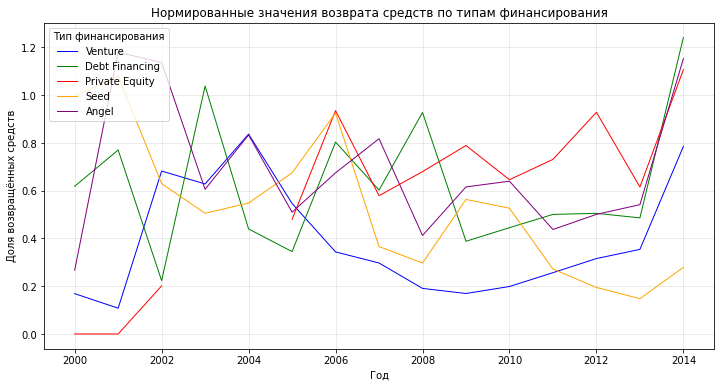

In [81]:
columns = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

colors = {
    'venture': 'blue',
    'debt_financing': 'green',
    'private_equity': 'red',
    'seed': 'orange',
    'angel': 'purple'
}

plt.figure(figsize=(12, 6))

for column in columns:
    plt.plot(
        normalized_values['year'],  
        normalized_values[column],              
        linewidth=1,
        color=colors[column],    
        label=column.replace('_', ' ').title()  
    )

plt.title('Нормированные значения возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвращённых средств')
plt.grid(True, alpha=0.3)
plt.legend(title='Тип финансирования')

plt.show()

Расчеты и график показывают, следующее:

- в типах финансирования 'debt_financing' и 'angel', чаще чем в других типах, возвраты  стремятся к 100% и даже превышают вложенные средства;
- доля возвратов по типам финансирования 'private_equity' и 'seed' лишь однажды превысила 100% (в 2014 и 2001 годах соответственно), в остальные годы процент возвратов не характеризуется стабильностью.
- несмотря на популярность венчурного типа финансирования и на большой объем возвратов, в сравнении с объемом вложенных средств он уже не является лидером. Доля возвратов по данному типу финансирования лишь в 2004 году превысила 80%.



## Шаг 5. Итоговый вывод и рекомендации

В ходе исследования проанализированы данные с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств. Цель анализа – помочь финансовой компании, работающей с венчурными инвестициями, понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Анализ был проведен на основе исторических данных.

<b>Ключевые выводы</b>

Исследовательский анализ данных позволил сформулировать следующие выводы:

* наибольшую долю финансирования от общего объёма привлечённых средств имеет категория "Срок финансирования более года" (больше 60%), наименьшую - "Срок финансирования до года" (меньше 10%);
* больше всего компаний, получивших аномальное финансирование, принадлежат к сегментам RealEstate, Entertainment, Consulting, Search и CloudComputing;
* львиная доля (более 70%) стартапов относится к нишевым сегментам, при том, что в каждом из нишевых сегментов занято меньше 35 компаний. Но в совокупности они занимают большую половину рынка;
* более 50 раундов финансирования было зафиксировано с 2000 по 2014 годы;
* в 2014 году наблюдалась отрицательная динамика по части среднего объема инвестиций за один раунд, а также количества самих раундов финансирования;
* несмотря на это, были и сегменты, показывающие рост размера суммарного финансирования в 2014 году по сравнению с 2013, а именно Apps, BigData, Design, Internet, Manufacturing, Medical, RealEstate, SaaS, Startups, Technology;
* финансирование по вышеперечисленным сегментам достигает своего пика к 2014 году. Начиная с 2004 года суммарное финансирование демонстрирует устойчивый рост с небольшим падением в 2009 году и далее непрерывным ростом к 2012-му. Незначительный спад был зафиксирован в 2013 году;
* наибольшей популярностью пользуется "венчурный" тип финансирования, он же лидирует по объемам предоставленных средств;
* несмотря на популярность венчурного типа финансирования и на большой объем возвратов, в сравнении с объемом вложенных средств он уже не является лидером. Доля возвратов по данному типу финансирования лишь в 2004 году превысила 80%;
* а вот в типах финансирования 'debt_financing' и 'angel', чаще чем в других типах, возвраты  стремятся к 100% и даже превышают вложенные средства.


<b>Рекомендации</b>

В качестве рекомендаций стоит обратить внимание на данные рынки: Apps, BigData, Design, Internet, Manufacturing, Medical, RealEstate, SaaS, Startups, Technology. Именно они показывали наибольший рост на 2014 год. Приоритетные типы финансирования - 'debt_financing' и 'angel'. Это лидеры по доле возврата вложенных средств.